## Build A Basic Chatbot With LangGraph(GRAPH API)

In [20]:
from langchain.chat_models import init_chat_model 
from langchain.tools import tool
from langgraph.graph import StateGraph, START, END, add_messages 
from langgraph.prebuilt import tools_condition, ToolNode
from dotenv import load_dotenv 
from typing_extensions import TypedDict, Annotated 

In [21]:
load_dotenv()

MODEL_NAME = "groq:qwen/qwen3-32b"
llm = init_chat_model(model = MODEL_NAME)

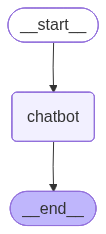

In [22]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]



## Node Functionality
def chatbot(state: State) -> State:
    return {"messages": [llm.invoke(state["messages"])]}

graph_builder = StateGraph(State)

## Adding node
graph_builder.add_node("chatbot", chatbot)

## Adding Edges
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

## compile the graph
graph = graph_builder.compile()
graph

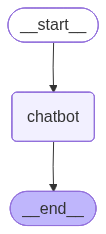

In [23]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [24]:
response = graph.invoke({"messages": "founder of HP. Just return the name"})
response['messages'][-1].content

'<think>\nOkay, the user is asking for the founder of HP and just wants the name. Let me recall. HP stands for Hewlett-Packard. I think the founders were Bill Hewlett and Dave Packard. They started the company in 1939. Let me make sure there are no other co-founders. No, it\'s definitely those two. The user specified to just return the name, so I should list both names, separated by a space or an "and"? The question says "founder" in singular, but there are two. Maybe they want both names. Let me check a quick source to confirm. Yes, Hewlett and Packard are the co-founders. The answer should be "Bill Hewlett and Dave Packard" or maybe their full names. Wait, sometimes it\'s written as "Hewlett and Packard" using their last names. The user might expect the full names. Bill Hewlett\'s full name is William R. Hewlett and Dave Packard is David Packard. But usually, they\'re referred to by their first names. Let me make sure. The common answer is Bill Hewlett and Dave Packard. So the answer

In [25]:
for event in graph.stream({"messages": "Who is the founder of NVIDIA? the output should be just the name"}):
    for value in event.values():
        print(value)

{'messages': [AIMessage(content='<think>\nOkay, I need to find out who founded NVIDIA. Let me start by recalling what I know about NVIDIA. It\'s a well-known company in the tech industry, especially in graphics processing units (GPUs) and AI. The founder might be someone prominent in that field.\n\nI think the name is associated with a couple of co-founders. I remember hearing about Jensen Huang. He\'s the current CEO, so it\'s possible he was one of the founders. But were there others? Maybe a couple of people. Let me try to remember. I think there was another person who co-founded NVIDIA with Jensen. Wait, was it Curtis Priem? No, Curtis Priem was with 3dfx. Maybe another name. I think one of the co-founders is named Chris or something similar. Wait, maybe it\'s Chris Malachowsky and Curtis Priem? No, Curtis Priem was at 3dfx. I\'m getting confused here.\n\nWait, NVIDIA was founded in 1993. The three co-founders are usually mentioned as Jensen Huang, Chris Malachowsky, and Curtis Pri

### Chatbot With Tool

- TavilySearch: Tavily is the real‑time search engine for AI agents and RAG workflows — Fast and secure APIs for web search and content extraction.

In [26]:
tavily_search_tool = TavilySearch(max_results = 2)
tavily_search_tool.invoke("what is langGraph")

{'query': 'what is langGraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the n

In [30]:
# customer function

@tool
def multiply(a:int, b:int) -> int:
    """Multiply a and b
    
    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """

    return a * b 


tools = [multiply,tavily_search_tool]

llm_with_tools = llm.bind_tools(tools)

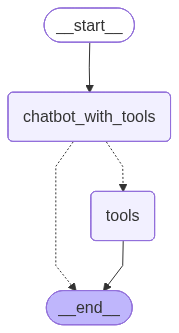

In [38]:
## Node Functionality
def chatbot_with_tools(state: State) -> State:
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder = StateGraph(State)

## Adding node
graph_builder.add_node("chatbot_with_tools", chatbot_with_tools)
graph_builder.add_node("tools", ToolNode(tools))

## Adding Edges
graph_builder.add_edge(START, "chatbot_with_tools")
graph_builder.add_conditional_edges(
    "chatbot_with_tools", 
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition)
graph_builder.add_edge("tools", END)

## compile the graph
graph = graph_builder.compile()
graph

In [35]:

response=graph.invoke({"messages":"What is the recent ai news"})

response['messages'][-1].content

"Here's a summary of recent AI news from the past week:\n\n**1. AI Tools & Innovations**  \n- **Acclaro**: Launched real-time AI subtitle translation into 100+ languages, plus audio processing for dubbing and voice cloning.  \n- **AdRoll**: Released Model Context Protocol (MCP) to integrate with AI platforms like ChatGPT for advertising insights.  \n- **LightSpeed Voice**: Nova Pro now uses AI for call transcription, script adherence analysis, and conversation summarization.  \n- **Liftoff**: Updated Cortex to AI-driven ad bidding adjustments for mobile apps using predictive user trend analysis.  \n- **Shirofune**: Added AI Summary feature to automate ad performance reports and optimization recommendations.  \n\n**2. Major Announcements & Trends**  \n- **OpenAI**: Plans to go public, intensifying competition with Anthropic.  \n- **Apple**: Overhauls Siri with new AI features ahead of Tim Cook's farewell.  \n- **Canada**: Prime Minister unveils national AI strategy focused on healthcare

In [36]:

for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the recent ai news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (p1scyksz9)
 Call ID: p1scyksz9
  Args:
    query: recent AI news
    search_depth: advanced
    time_range: week
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://martech.org/the-latest-ai-powered-martech-news-and-releases", "title": "The latest AI-powered martech news and releases", "content": "## May 28, 2026\n\nAcclaro launched Acclaro Multimedia Orchestration, a tool for global content distribution. Artificial intelligence translates subtitles into more than 100 languages in real time. Acclaro also processes audio for dubbing, voice cloning, and audio separation.\n\nAdRoll introduced

In [37]:
response=graph.invoke({"messages":"What is 5 multiplied by 2"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiplied by 2
================================== Ai Message ==================================
Tool Calls:
  multiply (tq8pnhe01)
 Call ID: tq8pnhe01
  Args:
    a: 5
    b: 2
================================= Tool Message =================================
Name: multiply

10
================================== Ai Message ==================================

The result of multiplying 5 by 2 is **10**. 

Let me know if you need help with anything else! 😊


### ReAct Agent Architecture

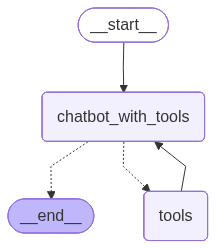

In [39]:
## Node Functionality
def chatbot_with_tools(state: State) -> State:
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder = StateGraph(State)

## Adding node
graph_builder.add_node("chatbot_with_tools", chatbot_with_tools)
graph_builder.add_node("tools", ToolNode(tools))

## Adding Edges
graph_builder.add_edge(START, "chatbot_with_tools")
graph_builder.add_conditional_edges(
    "chatbot_with_tools", 
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition)
graph_builder.add_edge("tools", "chatbot_with_tools")
graph_builder.add_edge("chatbot_with_tools", END)

## compile the graph
graph = graph_builder.compile()
graph

In [40]:

response=graph.invoke({"messages":"Give me the recent ai news and then multiply 5 by 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Give me the recent ai news and then multiply 5 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (63psjr2a7)
 Call ID: 63psjr2a7
  Args:
    query: recent AI news
    time_range: day
  multiply (827d0c8rp)
 Call ID: 827d0c8rp
  Args:
    a: 5
    b: 10
================================= Tool Message =================================
Name: tavily_search

No search results found for 'recent AI news'. Suggestions: Remove time_range argument, Try a more detailed search using 'advanced' search_depth. Try modifying your search parameters with one of these approaches.
================================= Tool Message =================================
Name: multiply

50
================================== Ai Message ==================================

The multiplication result is **50**.

For the recent AI news search, no results were found with the init

### Adding Memory In Agentic Graph

In [41]:

response=graph.invoke({"messages":"Hello my name is KRish"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is KRish
================================== Ai Message ==================================

Hello KRish! How can I assist you today?


In [42]:

response=graph.invoke({"messages":"What is my name"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my name
================================== Ai Message ==================================

I don't have access to your personal information, including your name. You'll need to tell me your name if you want me to address you by it or help with any personalized queries. How can I assist you today?


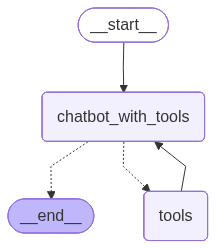

In [45]:
from langgraph.checkpoint.memory import MemorySaver 

memory = MemorySaver()

## Node Functionality
def chatbot_with_tools(state: State) -> State:
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder = StateGraph(State)

## Adding node
graph_builder.add_node("chatbot_with_tools", chatbot_with_tools)
graph_builder.add_node("tools", ToolNode(tools))

## Adding Edges
graph_builder.add_edge(START, "chatbot_with_tools")
graph_builder.add_conditional_edges(
    "chatbot_with_tools", 
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition)
graph_builder.add_edge("tools", "chatbot_with_tools")
graph_builder.add_edge("chatbot_with_tools", END)

## compile the graph
graph = graph_builder.compile(checkpointer = memory)
graph

In [46]:
config={"configurable":{"thread_id":"1"}}
response=graph.invoke({"messages":"Hello my name is KRish"}, config=config)
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is KRish
================================== Ai Message ==================================

Hello KRish! How can I assist you today? If you have any questions or need help with something specific, feel free to let me know! 😊


In [48]:
response=graph.invoke({"messages":"Hey do you remember my name"},config=config)
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello my name is KRish
================================== Ai Message ==================================

Hello KRish! How can I assist you today? If you have any questions or need help with something specific, feel free to let me know! 😊
================================ Human Message =================================

Hey do you remember mmy name
================================== Ai Message ==================================

Yes, I remember your name! It's KRish. 😊 How can I assist you today?
================================ Human Message =================================

Hey do you remember my name
================================== Ai Message ==================================

Yes, of course! Your name is KRish. 😊 How can I assist you today?


### Streaming

**Methods**: .stream() and astream()

These methods are sync and async methods for streaming back results.
Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

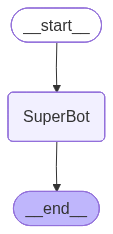

In [49]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()
def superbot(state:State):
    return {"messages":[llm.invoke(state['messages'])]}
graph=StateGraph(State)

## node
graph.add_node("SuperBot",superbot)
## Edges

graph.add_edge(START,"SuperBot")
graph.add_edge("SuperBot",END)


graph_builder=graph.compile(checkpointer=memory)

graph_builder

In [50]:
## Invocation

config = {"configurable": {"thread_id": "1"}}

graph_builder.invoke({'messages':"Hi,My name is Krish And I like cricket"},config)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='6d07dd30-5a6c-47e8-b896-4e16e465bfb9'),
  AIMessage(content='<think>\nOkay, the user introduced themselves as Krish and mentioned they like cricket. Let me start by acknowledging their introduction. I should respond in a friendly and welcoming manner. Maybe say something like "Hi Krish!" to make it personal.\n\nSince they mentioned liking cricket, I can ask them about their favorite team or player to keep the conversation going. That shows I\'m interested in their perspective. I should also share a bit about cricket to show I know a little, maybe mention that it\'s popular in countries like India, Pakistan, Australia, etc.\n\nI need to keep the tone positive and open-ended to encourage them to share more. Maybe ask if they play the game or just watch it. That way, I can get more details about their interest. Also, avoid any assumptions, like not assuming they are

In [51]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="<think>\nOkay, the user is Krish, and he mentioned he likes cricket. Let me start by greeting him and acknowledging his interest. I should make sure to respond in a friendly and engaging way. Maybe ask him about his favorite team or player to keep the conversation going. Also, I could mention some recent cricket events or the IPL if he's interested. I need to keep it conversational and not too formal. Let me check if there's any recent news in cricket to include, but if not, just a general question about his favorite part of the game. Alright, time to put it all together.\n</think>\n\nHi Krish! Nice to meet you! 🏏 I love that you're into cricket—it's such an exciting game! Do you have a favorite team or player? Also, are you following any upcoming matches or tournaments, like the IPL? Let me know what part of the game you enjoy the most—batting, bowling, or fielding? 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_t

In [52]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Krish And I like cricket"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Krish And I like cricket', additional_kwargs={}, response_metadata={}, id='4c8bce1c-a652-4f85-91cd-5954692139b6'), AIMessage(content="<think>\nOkay, the user is Krish, and he mentioned he likes cricket. Let me start by greeting him and acknowledging his interest. I should make sure to respond in a friendly and engaging way. Maybe ask him about his favorite team or player to keep the conversation going. Also, I could mention some recent cricket events or the IPL if he's interested. I need to keep it conversational and not too formal. Let me check if there's any recent news in cricket to include, but if not, just a general question about his favorite part of the game. Alright, time to put it all together.\n</think>\n\nHi Krish! Nice to meet you! 🏏 I love that you're into cricket—it's such an exciting game! Do you have a favorite team or player? Also, are you following any upcoming matches or tournaments, like the IPL? Let me know what par

In [53]:
config = {"configurable": {"thread_id": "5"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019eabda-ff84-7753-b16e-cb6af55ddc3d', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi My name is Krish and I like to play cricket', additional_kwargs={}, response_metadata={}, id='9d833e05-42a1-4a8d-87b5-62437dbf4923')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '019eabda-ffce-72c2-8d00-c6894d1bb479', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:18066cf7-e93d-905e-94ed-581863e46905'}, 'parent_ids': ['019eabda-ff84-7753-b16e-cb6af55ddc3d']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages':